# The tradeSeq workflow

Python port of the canonical R vignette `vignettes/tradeSeq.Rmd`.
`tradeSeq` fits a negative-binomial generalized additive model (NB-GAM)
to every gene along each trajectory lineage and exposes a battery of
Wald-style tests for differential expression.

This notebook reproduces the analysis on the bundled Paul-2015 myeloid
progenitor dataset. Trajectory artifacts (`pseudotime`, `cell_weights`,
principal curves) were computed once on the R side via slingshot 2.8.0
and frozen into `tradeseq/resources/paul15_tradeseq.h5ad`; the Python
package therefore depends on no trajectory-inference library at
runtime.


## Installation

```bash
pip install tradeSeq-python
```


## Load data

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Image, display

import ggplot2_py as g
from grid_py import get_state, grid_newpage
from patchwork._display import gtable_to_png
from patchwork.core import patchworkGrob

import tradeseq as ts


def show_plot(plot, *, width, height):
    plot.fig_width = width
    plot.fig_height = height
    display(plot)


def show_patchwork(plot, *, width, height, dpi=150):
    png = gtable_to_png(patchworkGrob(plot), width=width, height=height, dpi=dpi)
    display(Image(data=png, format='png'))


def show_heatmap(plot, *, width, height, dpi=150):
    grid_newpage(width=width, height=height, dpi=dpi)
    plot.draw()
    display(Image(data=get_state().get_renderer().to_png_bytes(), format='png'))


adata = ts.load_paul15()
adata


AnnData object with n_obs × n_vars = 2660 × 240
    obs: 'cluster', 'celltype'
    uns: 'provenance', 'slingshot'
    obsm: 'X_umap', 'cell_weights', 'pseudotime'
    layers: 'counts'

The R `crv`, `countMatrix`, and `celltype` datasets are packed into a
single AnnData:

- `adata.layers["counts"]` — raw count matrix (`cells × genes`)
- `adata.obs["cluster"]`, `adata.obs["celltype"]` — categorical metadata
- `adata.obsm["X_umap"]` — 2-D UMAP
- `adata.obsm["pseudotime"]` — `slingPseudotime(crv, na=FALSE)`
- `adata.obsm["cell_weights"]` — `slingCurveWeights(crv)`
- `adata.uns["slingshot"]["curves"]` — per-lineage `s, ord, lambda`

Per the scverse mapping (`tradeseq_porting_essential_suggestions.md` §1),
the five R accessor functions (`slingPseudotime`, `slingCurveWeights`,
`slingClusterLabels`, `slingCurves`, `slingReducedDim`) are not ported as
Python symbols — users read the AnnData slots directly.


## Fit negative binomial model

Choosing the number of knots is done with `evaluate_k`.

In [2]:
aic_mat = ts.evaluate_k2(
    adata,
    k_range=range(3, 8),
    n_genes=200,
    plot=False,
    random_state=5,
)
aic_mat.shape

evaluate_k2 k=3:   0%|          | 0/200 [00:00<?, ?it/s]

evaluate_k2 k=4:   0%|          | 0/200 [00:00<?, ?it/s]

evaluate_k2 k=5:   0%|          | 0/200 [00:00<?, ?it/s]

evaluate_k2 k=6:   0%|          | 0/200 [00:00<?, ?it/s]

evaluate_k2 k=7:   0%|          | 0/200 [00:00<?, ?it/s]

(200, 5)

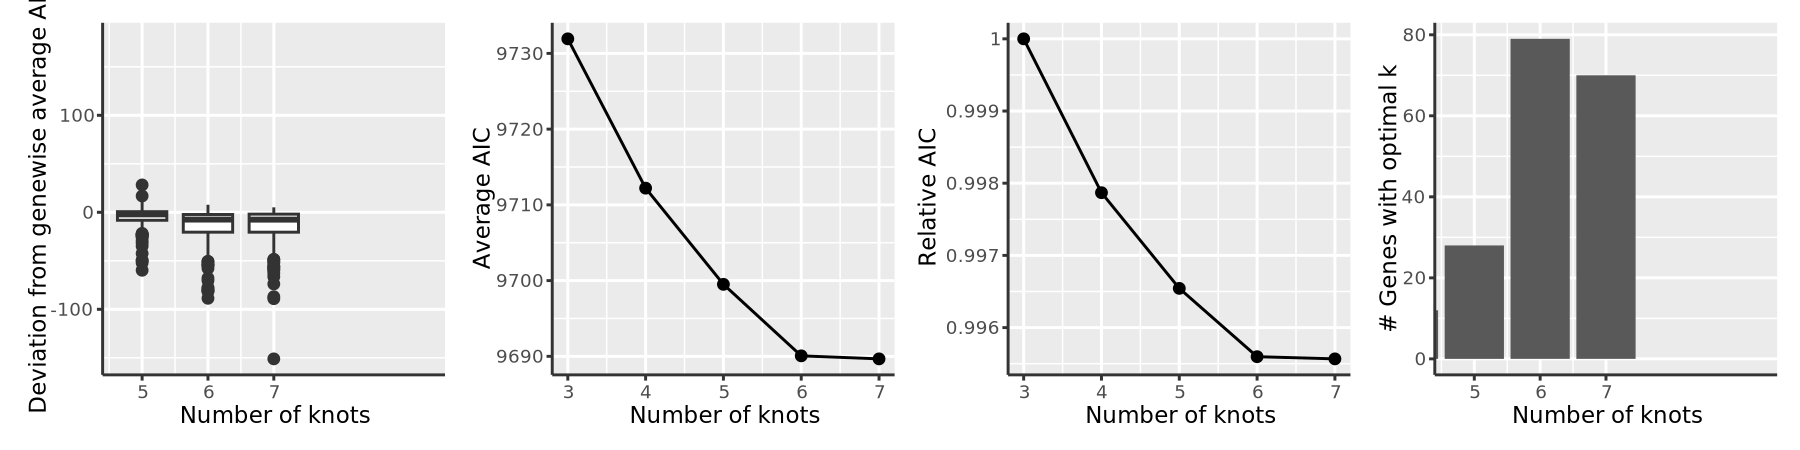

In [3]:
ts.plot_evaluatek_results(aic_mat, k_range=range(3, 8))

Following the R vignette, we choose `n_knots = 6` and fit all genes in
the bundled Paul15 dataset.


In [4]:
# For reproducibility.
rng = np.random.default_rng(7)
probs = adata.obsm['cell_weights'] / adata.obsm['cell_weights'].sum(axis=1, keepdims=True)
w_samp = np.zeros_like(adata.obsm['cell_weights'], dtype=np.int64)
for i in range(adata.n_obs):
    w_samp[i] = rng.multinomial(1, probs[i])

a = adata.copy()
ts.fit_gam(a, n_knots=6, verbose=False, _w_samp=w_samp)
a

AnnData object with n_obs × n_vars = 2660 × 240
    obs: 'cluster', 'celltype'
    var: 'tradeseq_converged'
    uns: 'provenance', 'slingshot', 'tradeseq'
    obsm: 'X_umap', 'cell_weights', 'pseudotime'
    varm: 'tradeseq_beta', 'tradeseq_Sigma'
    layers: 'counts'

Some genes may not converge — typically due to extreme sparsity. The
convergence flag is stored in `adata.var["tradeseq_converged"]`:


In [5]:
a.var['tradeseq_converged'].value_counts()

tradeseq_converged
True    240
Name: count, dtype: int64

Knot positions are stored in `adata.uns["tradeseq"]["knots"]`:


In [6]:
ts.nknots(a)

6

# Within-lineage comparisons

## Association of gene expression with pseudotime

`association_test` tests the null hypothesis that all smoother
coefficients are equal — i.e. that average gene expression is constant
along pseudotime within a lineage.


In [7]:
asso_res = ts.association_test(a)
asso_res.head()

,waldStat,df,pvalue,meanLogFC
gene,,,,
Acin1,119.437205,10.0,6.581702e-21,0.351740
Actb,NaN,NaN,NaN,0.560318
Ak2,NaN,NaN,NaN,0.641569
Alad,174.196200,10.0,3.747757e-32,0.630432
Alas1,NaN,NaN,NaN,0.991207


## Discovering progenitor marker genes

`start_vs_end_test` performs a multivariate Wald test comparing the
smoother value at the start of a lineage to the value at the end.


In [8]:
start_res = ts.start_vs_end_test(a)
start_res.head()


,waldStat,df,pvalue,logFClineage1,logFClineage2
gene,,,,,
Acin1,4.652596,2.0,9.765659e-02,0.353129,0.124302
Actb,210.325826,2.0,2.129743e-46,0.747818,0.278804
Ak2,65.470941,2.0,6.069679e-15,0.795225,0.805708
Alad,94.907456,2.0,2.460978e-21,-0.620500,1.615774
Alas1,972.717610,2.0,5.984870e-212,3.549006,-0.085415


Visualise the estimated smoothers for the 3rd most significant gene:


In [ ]:
o_start = start_res['waldStat'].sort_values(ascending=False).index
sig_gene_start = o_start[2]
print('sig_gene_start =', sig_gene_start)

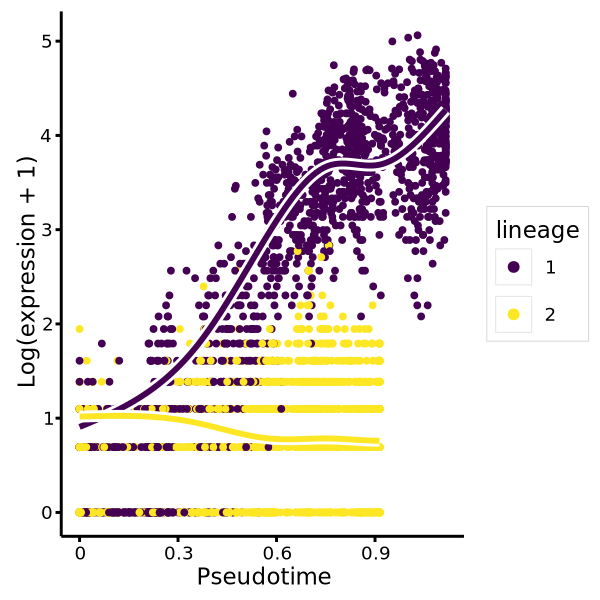

In [48]:
show_plot(ts.plot_smoothers(a, gene=sig_gene_start, lwd=1), width=4, height=4)

And colour cells in UMAP space by that gene's expression:

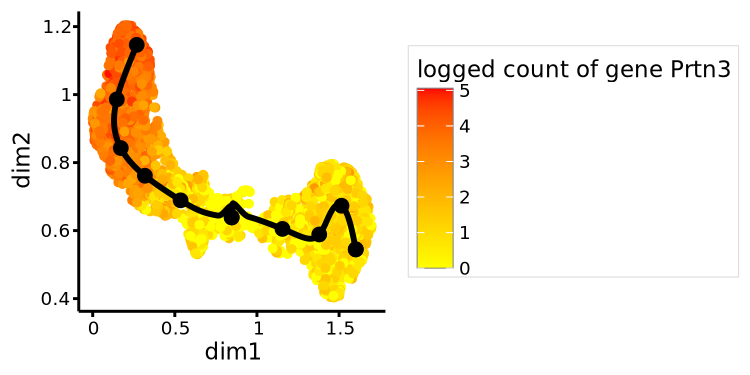

In [10]:
show_plot(ts.plot_gene_count(a, gene=sig_gene_start), width=5, height=2.5)


## Comparing specific pseudotime values within a lineage

`start_vs_end_test` can compare any two pseudotime values, not just the
endpoints. To check expression at `t = 0.1` vs `t = 0.8`:


In [11]:
custom_res = ts.start_vs_end_test(a, pseudotime_values=(0.1, 0.8))
custom_res.head()


,waldStat,df,pvalue,logFClineage1,logFClineage2
gene,,,,,
Acin1,16.155254,2.0,3.104068e-04,0.042203,0.406460
Actb,359.128290,2.0,1.038204e-78,0.571275,0.251141
Ak2,78.544938,2.0,8.793937e-18,0.607145,0.602433
Alad,101.925391,2.0,7.365168e-23,-0.146656,1.181330
Alas1,972.470457,2.0,6.772101e-212,2.227593,-0.065425


# Between-lineage comparisons

## Discovering differentiated cell type markers

`diff_end_test` tests whether the average expression at the endpoints
is equal between lineages.


In [12]:
end_res = ts.diff_end_test(a)
end_res.head()


,waldStat,df,pvalue,logFC1_2
gene,,,,
Acin1,10.730506,1.0,1.053836e-03,0.295962
Actb,173.195999,1.0,1.483083e-39,0.399808
Ak2,10.776231,1.0,1.028118e-03,-0.212237
Alad,364.347072,1.0,3.184470e-81,-2.345959
Alas1,1522.408250,1.0,0.000000e+00,3.368225


In [ ]:
o_end = end_res['waldStat'].sort_values(ascending=False).index
sig_gene_end = o_end[0]
print('sig_gene_end =', sig_gene_end)

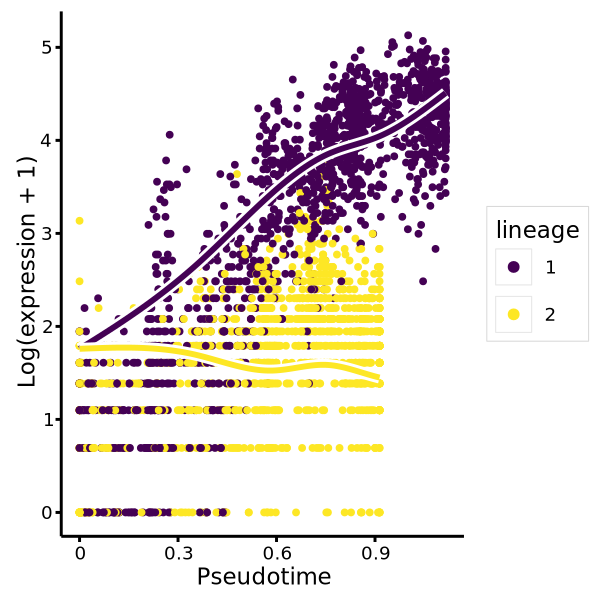

In [40]:
show_plot(ts.plot_smoothers(a, gene=sig_gene_end, lwd=1), width=4, height=4)

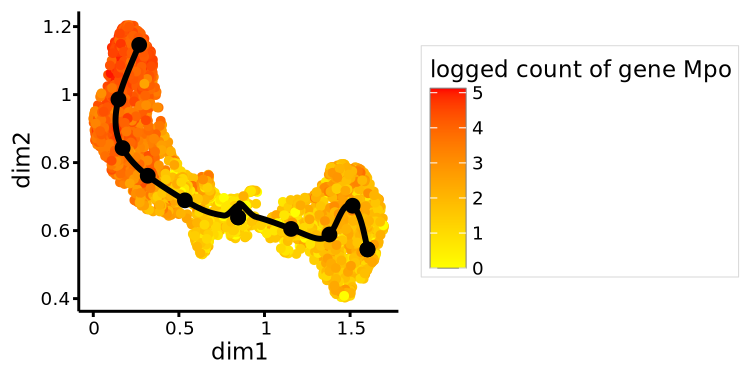

In [14]:
show_plot(ts.plot_gene_count(a, gene=sig_gene_end), width=5, height=2.5)


## Discovering genes with different expression patterns

`pattern_test` tests whether smoothed expression curves are equal
between lineages at `2 * n_knots` equally-spaced pseudotime points.


In [ ]:
pattern_res = ts.pattern_test(a)
o_pat = pattern_res['waldStat'].sort_values(ascending=False).index
print(list(o_pat[:6]))

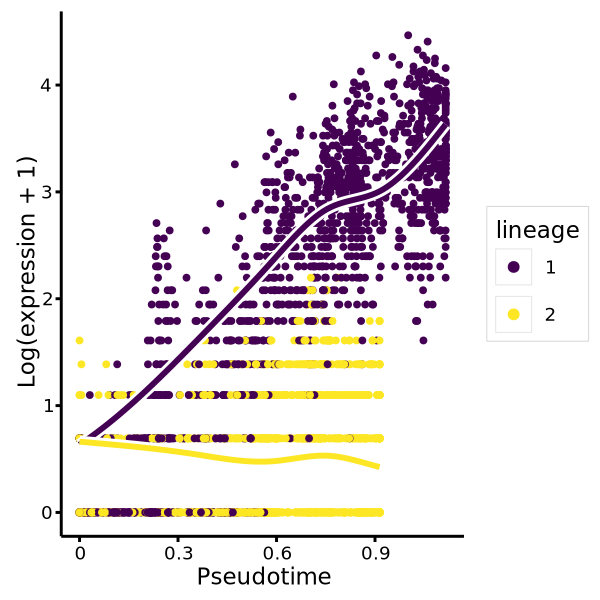

In [38]:
show_plot(ts.plot_smoothers(a, gene=o_pat[3], lwd=1), width=4, height=4)

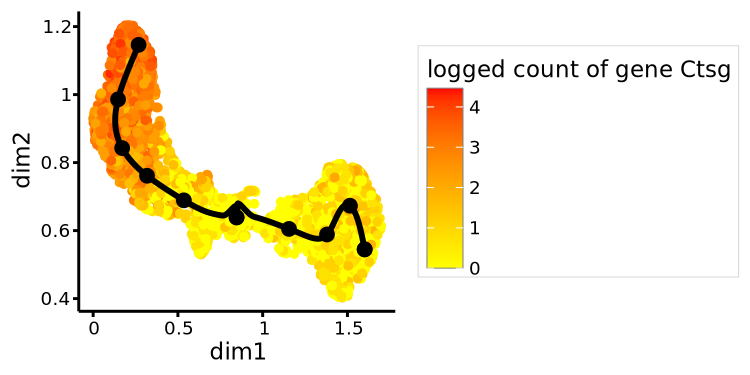

In [16]:
show_plot(ts.plot_gene_count(a, gene=o_pat[3]), width=5, height=2.5)


`pattern_test` (and `early_de_test`) takes an `eigen_thresh` keyword
controlling the rank threshold of the contrast's covariance matrix.
Lower values are more lenient; the default `1e-2` favours numerical
stability over inclusivity.


### Example on combining `pattern_test` with `diff_end_test` results

Genes that have a different expression *pattern* between lineages but
no different *endpoint* expression are the most interesting transient-
expression candidates. Score them by a sum-of-squares of the two
Wald-statistic ranks:


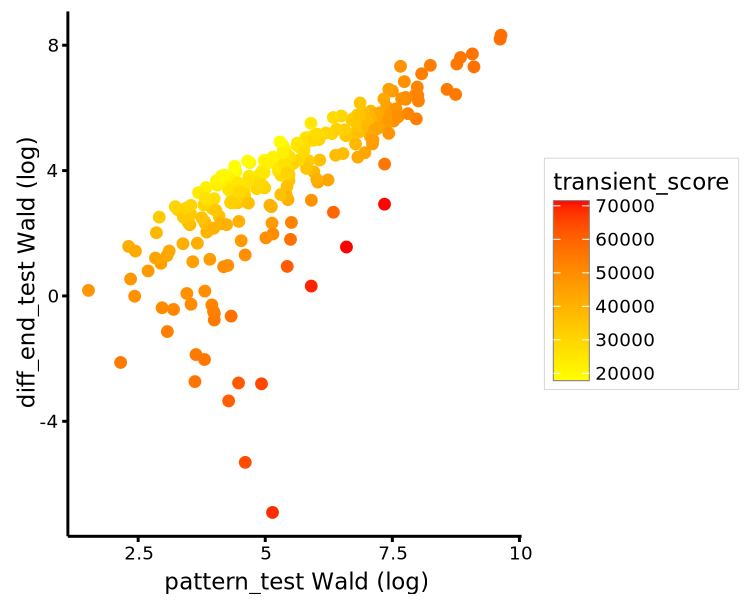

In [17]:
compare = (
    pattern_res.rename(columns={'waldStat': 'pattern'})[['pattern']]
    .join(end_res.rename(columns={'waldStat': 'end'})[['end']], how='inner')
)
compare['transient_score'] = (
    (-compare['end']).rank(method='min').astype(int) ** 2
    + compare['pattern'].rank(method='min').astype(int) ** 2
)
compare['log_pattern'] = np.log(compare['pattern'].clip(lower=1e-3))
compare['log_end'] = np.log(compare['end'].clip(lower=1e-3))
transient_plot = (
    g.ggplot(compare, g.aes(x='log_pattern', y='log_end'))
    + g.geom_point(g.aes(colour='transient_score'))
    + g.labs(x='pattern_test Wald (log)', y='diff_end_test Wald (log)')
    + g.scale_color_gradient(low='yellow', high='red')
    + g.theme_classic()
)
show_plot(transient_plot, width=5, height=4)


top_transient = Irf8


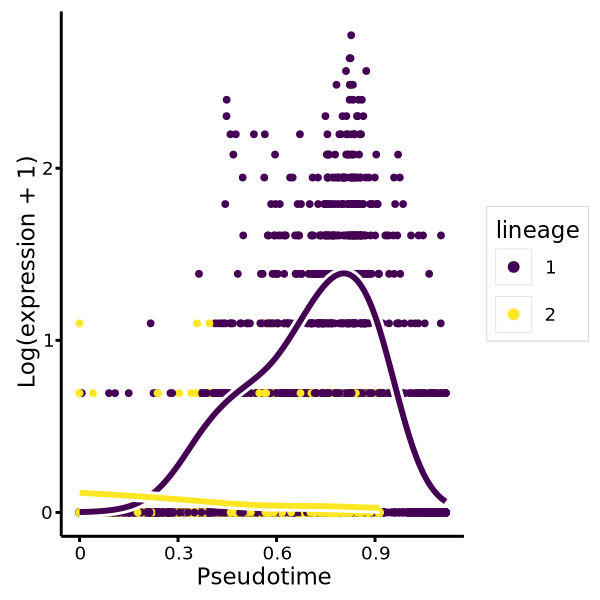

In [37]:
top_transient = compare['transient_score'].idxmax()
print('top_transient =', top_transient)
show_plot(ts.plot_smoothers(a, gene=top_transient, lwd=1), width=4, height=4)


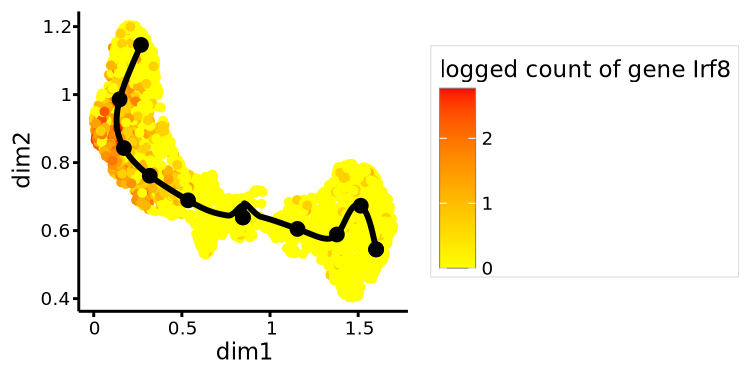

In [19]:
show_plot(ts.plot_gene_count(a, gene=top_transient), width=5, height=2.5)


The top 5 transient-expression candidates by this ranking:


In [20]:
compare.sort_values('transient_score', ascending=False).head(5).index.tolist()


['Irf8', 'Mt1', 'Nedd4', 'Hint1', 'Myc']

If your dataset contains the classic Irf8 progenitor marker, this is
the place where the R vignette inspects it. Try:


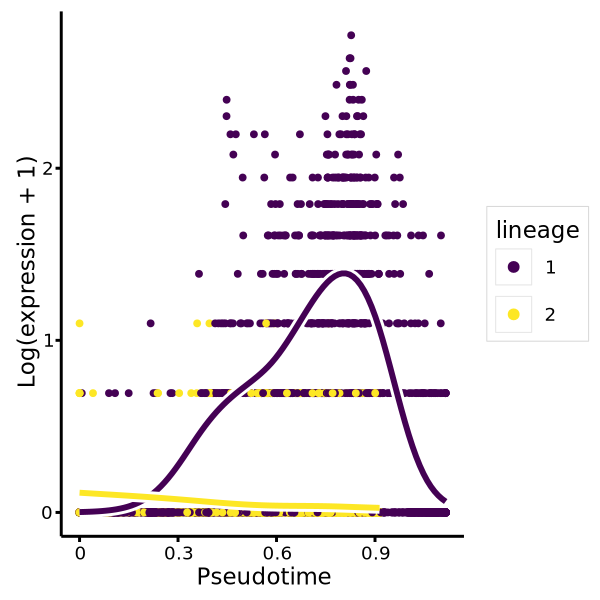

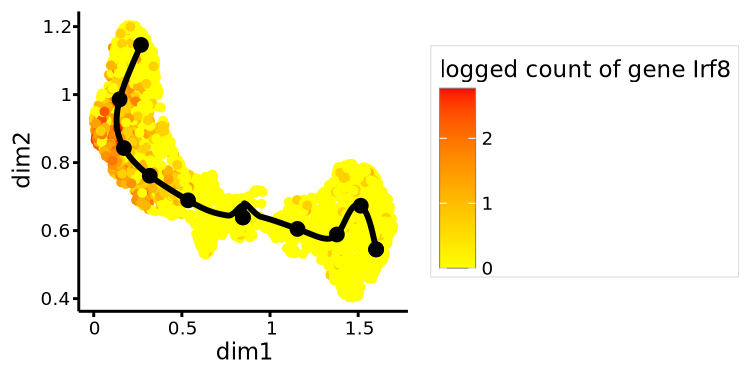

In [42]:
if 'Irf8' in a.var_names:
    show_plot(ts.plot_smoothers(a, gene='Irf8', lwd=1), width=4, height=4)
    show_plot(ts.plot_gene_count(a, gene='Irf8'), width=5, height=2.5)


## Early drivers of differentiation

`early_de_test(adata, knots=(k_low, k_high))` tests whether the
smoothed expression curves are equal between lineages in the pseudotime
region bounded by knots `k_low` and `k_high`. Setting `knots=(1, 2)`
probes early differentiation right after the bifurcation.


As in the R vignette, first show the fitted knot positions on the
trajectory, coloured by cluster assignment:


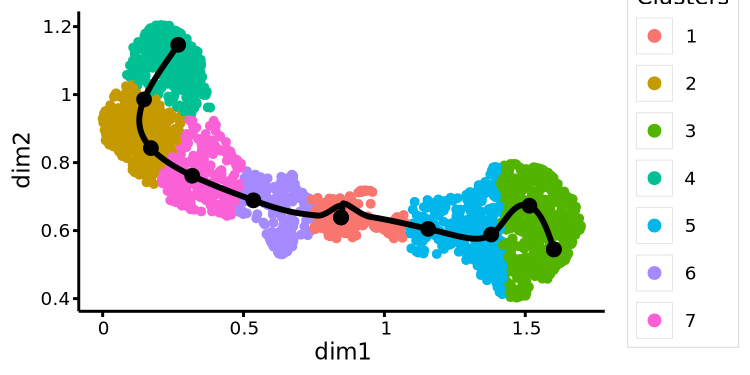

In [22]:
show_plot(ts.plot_gene_count(a, clusters_key='cluster'), width=5, height=2.5)


In [ ]:
early_de_res = ts.early_de_test(a, knots=(1, 2))
o_early = early_de_res['waldStat'].sort_values(ascending=False).index

['Car1', 'Car2', 'Klf1', 'Vim', 'Mt1', 'Vamp5']


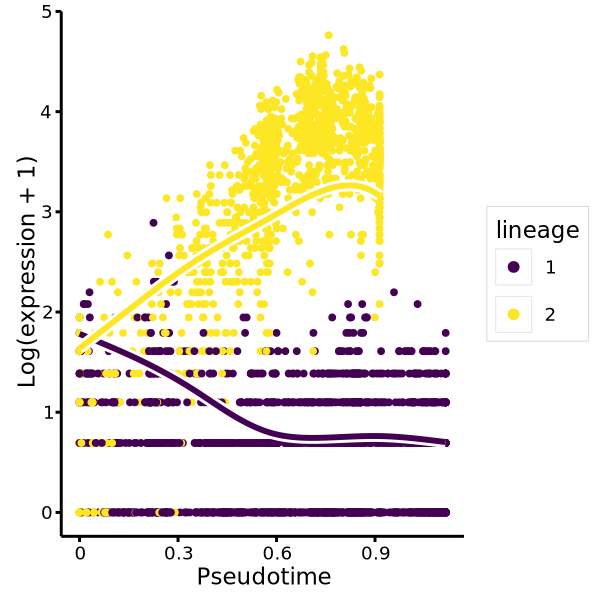

In [35]:
print(list(o_early[:6]))
show_plot(ts.plot_smoothers(a, gene=o_early[1], lwd=1), width=4, height=4)

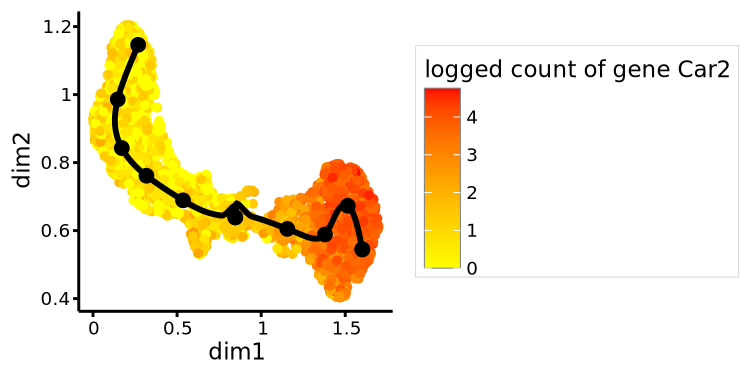

In [24]:
show_plot(ts.plot_gene_count(a, gene=o_early[1]), width=5, height=2.5)


# Differential expression in large datasets

Large datasets can render statistically significant fold changes that
are biologically inconsequential. Every Wald test accepts an `l2fc`
argument that specifies the absolute log2-fold-change cut-off; only
genes whose effect exceeds this cut-off are reported as significant.


In [25]:
# Testing against a fold-change threshold of 2.
start2 = ts.start_vs_end_test(a, l2fc=np.log2(2))
# Testing against a fold-change threshold of 1.5.
pat2 = ts.pattern_test(a, l2fc=np.log2(1.5))
start2.head(), pat2.head()


(         waldStat   df         pvalue  logFClineage1  logFClineage2
 gene                                                               
 Acin1    0.000000  2.0   1.000000e+00       0.353129       0.124302
 Actb     0.956879  2.0   6.197498e-01       0.747818       0.278804
 Ak2      1.191807  2.0   5.510645e-01       0.795225       0.805708
 Alad    28.488965  2.0   6.511783e-07      -0.620500       1.615774
 Alas1  629.773722  2.0  1.763494e-137       3.549006      -0.085415,
           waldStat   df         pvalue  fcMedian
 gene                                            
 Acin1     0.000000  6.0   1.000000e+00  0.108700
 Actb      0.000000  7.0   1.000000e+00  0.230383
 Ak2       0.000000  6.0   1.000000e+00  0.263810
 Alad    689.522197  6.0  1.118622e-145  1.205331
 Alas1  1477.190520  2.0   0.000000e+00  1.551018)

# Clustering of genes according to their expression pattern

## Extracting fitted values to use with any clustering method

Use `predict_cells` to get fitted means per cell (count scale) and
`predict_smooth` for a uniform grid along each lineage. Both are
suitable inputs for any clustering method.


In [26]:
yhat = ts.predict_cells(a, gene='Irf8') if 'Irf8' in a.var_names else ts.predict_cells(a, gene=str(a.var_names[0]))
yhat.shape


(1, 2660)

In [27]:
y_smooth = ts.predict_smooth(
    a, gene=('Irf8' if 'Irf8' in a.var_names else str(a.var_names[0])),
    n_points=40,
)
y_smooth.head()


,lineage,time,gene,yhat
0,1,0.000000,Irf8,0.002230
1,1,0.028596,Irf8,0.003853
2,1,0.057192,Irf8,0.006631
3,1,0.085788,Irf8,0.011319
4,1,0.114384,Irf8,0.019082


## Clustering using RSEC, clusterExperiment

The R package uses `clusterExperiment::RSEC` (resampling-based
sequential ensemble clustering); the Python port substitutes
`sklearn.cluster.AgglomerativeClustering` with silhouette-based `k`
selection.

In python version, if n_clusters is not specified, then will automatic determine a cluster number.

In [49]:
clus_res = ts.cluster_expression_patterns(
    a, n_points=20, genes=list(a.var_names[:100]), n_clusters=4
)  
clus_df = clus_res.long_df
clus_df.head()


,gene,cluster,profile,time_point
0,Acin1,0,-1.616783,l1:t0.0
1,Acin1,0,-1.116656,l1:t0.05869704337254684
2,Acin1,0,-0.647679,l1:t0.11739408674509368
3,Acin1,0,-0.241001,l1:t0.17609113011764052
4,Acin1,0,0.072228,l1:t0.23478817349018735


In [50]:
clus_df.cluster.unique()

array([0, 3, 2, 1])

Visualise the first four clusters' normalized expression curves:


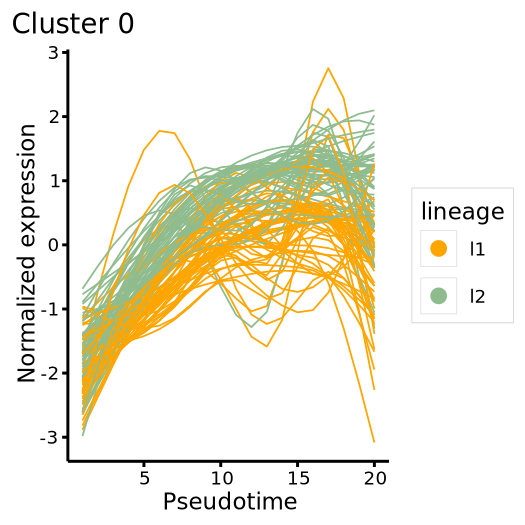

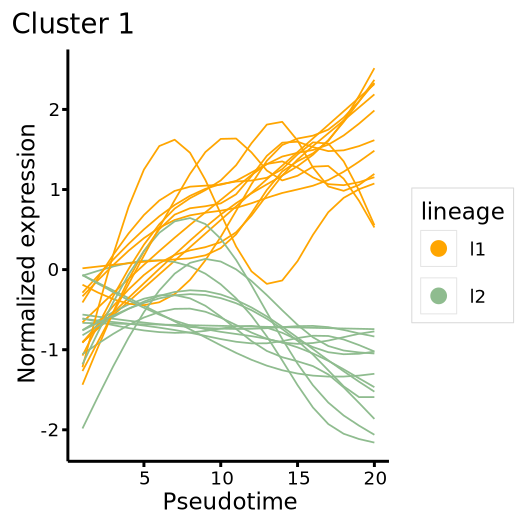

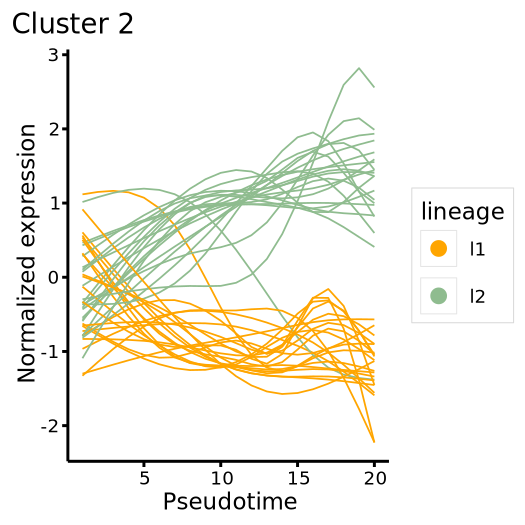

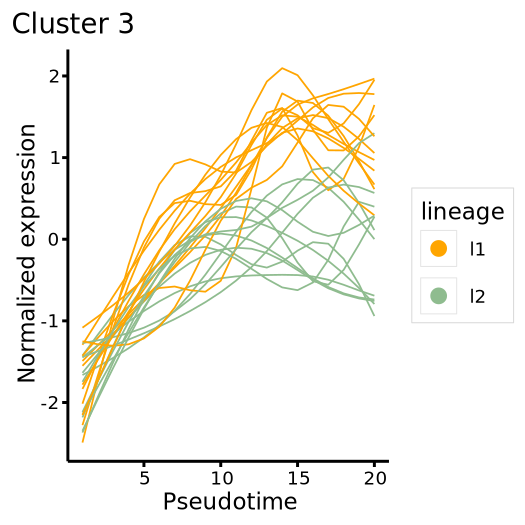

In [51]:
# `time_point` is encoded as 'l<lineage>:t<pseudotime>' -- split it.
tp = clus_df['time_point'].astype(str).str.split(':', n=1, expand=True)
clus_df = clus_df.assign(lineage=tp[0])
clus_df['point'] = clus_df.groupby(['gene', 'lineage'], sort=False).cumcount() + 1

cluster_ids = [k for k in sorted(clus_df['cluster'].unique()) if k != -1]
for k in cluster_ids[:4]:
    sub = clus_df[clus_df['cluster'] == k].copy()
    sub['gene_lineage'] = sub['gene'].astype(str) + '_' + sub['lineage'].astype(str)
    range_df = pd.DataFrame({
        'point': [1, 20],
        'profile': [sub['profile'].min(), sub['profile'].max()],
    })
    p = (
        g.ggplot(sub, g.aes(x='point', y='profile',
                            group='gene_lineage', colour='lineage'))
        + g.geom_blank(data=range_df,
                       mapping=g.aes(x='point', y='profile'),
                       inherit_aes=False)
        + g.geom_line(linewidth=.3, show_legend=False)
        + g.scale_color_manual(values=['orange', 'darkseagreen'],
                               breaks=['l1', 'l2'])
        + g.labs(title=f'Cluster {k}',
                 x='Pseudotime', y='Normalized expression')
        + g.theme_classic()
    )
    show_plot(p, width=3.5, height=3.5)


## Cascades of transient expression along a lineage

The R `cascade` export computes genes whose fitted expression is
significantly increasing along a lineage, orders them by the first
post-increase peak time, and can draw a heatmap. In Python the
calculation and rendering are split: `cascade` returns a `CascadeResult`,
and `plot_cascade` renders that result with `pheatmap`.


In [30]:
cascade_res = ts.cascade(a, lineage=1, n_points=100)
print(f'{cascade_res.peak_time.shape[0]} cascade genes')
cascade_res.peak_time.head()

183 cascade genes


Acin1    0.957533
Actb     0.394278
Ak2      0.968798
Alas1    1.115244
Aldoa    1.115244
Name: peakTime, dtype: float64

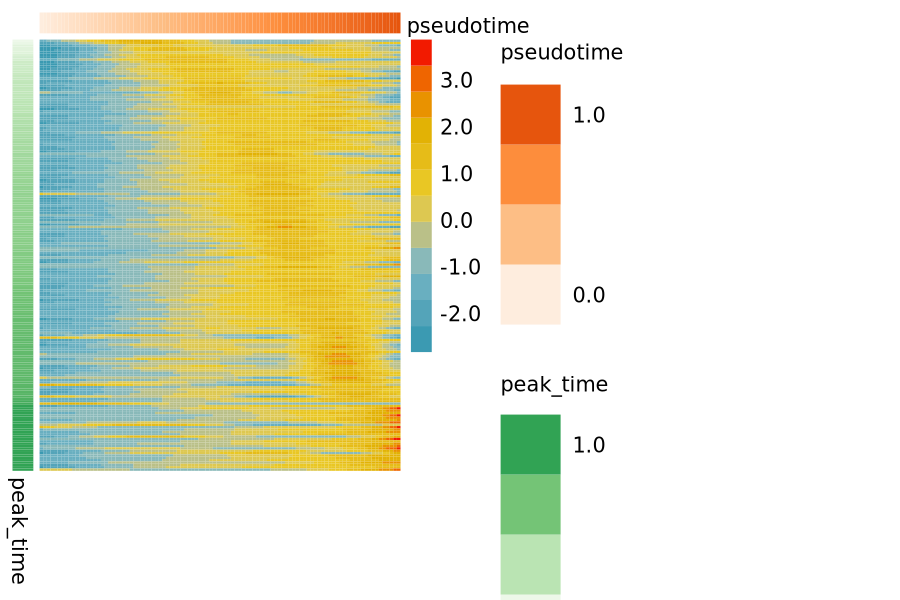

In [54]:
cascade_plot = ts.plot_cascade(cascade_res, silent=True, show_gene_names=False)
show_heatmap(cascade_plot, width=6, height=4)

# Wrap-up

We've walked through tradeSeq's full Wald battery:

- **Foundation**: `fit_gam`, `nknots`, `evaluate_k`,
  `plot_evaluatek_results`
- **Within-lineage**: `association_test`, `start_vs_end_test`
- **Between-lineage**: `diff_end_test`, `pattern_test`,
  `early_de_test`, `condition_test`
- **Prediction**: `predict_cells`, `predict_smooth`
- **Visualization**: `plot_smoothers`, `plot_gene_count`, `plot_cascade`
- **Downstream**: `cluster_expression_patterns`, `cascade`,
  `get_smoother_pvalues`, `get_smoother_test_stats`

The accompanying `fitGAM.ipynb` notebook goes deeper into model-fitting
options (covariates, parallelism, list-mode output, convergence
diagnostics).
